This notebook demonstrates how to use learned optimizers in the VeLO family on

1) a simple image recognition task

and

2) resnets


This notebook installs dependencies in the first cell, and is compatible with any runtime, though it works best with TPU and GPU runtimes.


If you would like to see a more pedagogical introduction to our learned optimization library, please take a look at our [introductory notebooks](https://github.com/google/learned_optimization#learned_optimization-tutorial-sequence).


* add baseline to resnet (param for opt)

In [ ]:
!pip install pymoo


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.1/249.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.1 MB/s eta 0:00:00
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210082 sha256=f8fde086e206fd1ba8139476d55e0bad01057dcf91cfc034280593fb99db3bdb
  Stored in directory: /root/.cache/pip/wheels/ee/3b/0b/1b865800e916d671a24028d884698674138632a83fdfad4926
Successfully built grapheme


In [ ]:
from pymoo.problems import get_problem


In [ ]:
!pip install dm-haiku


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.9/373.9 kB 17.4 MB/s eta 0:00:00


In [ ]:
#@title Accelerator Setup, Library Instillation, and Imports (Run this cell first!)

Accelerator_Type = 'CPU' #@param ["GPU", "TPU", "CPU"]

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)


# install lopt
#!pip install git+https://github.com/google/learned_optimization.git
#Added
!git clone https://github.com/google/learned_optimization.git
%cd learned_optimization
# Modifier setup.py ici (retirer ou commenter la ligne dm-launchpad)
!pip install .

import jax
if Accelerator_Type == 'TPU':
  import jax.tools.colab_tpu
  jax.tools.colab_tpu.setup_tpu()

from learned_optimization.tasks.fixed import image_mlp
from learned_optimization.research.general_lopt import prefab
from learned_optimization import eval_training

from matplotlib import pylab as plt
from learned_optimization import notebook_utils as nu
import numpy as onp


from learned_optimization.baselines import utils
import os
# use the precomputed baselines folder from gcp for loading baseline training curves
os.environ["LOPT_BASELINE_ARCHIVES_DIR"] = "gs://gresearch/learned_optimization/opt_archives/"


/bin/bash: line 1: nvidia-smi: command not found
Cloning into 'learned_optimization'...
remote: Enumerating objects: 2551, done.
remote: Counting objects: 100% (675/675), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 2551 (delta 560), reused 524 (delta 520), pack-reused 1876 (from 2)
Receiving objects: 100% (2551/2551), 6.45 MiB | 8.55 MiB/s, done.
Resolving deltas: 100% (1860/1860), done.
/content/learned_optimization
Processing /content/learned_optimization
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of learned-optimization to determine which version is compatible with other requirements. This could take a while.
ERROR: Could not find a version that satisfies the requirement dm-launchpad-nightly (from learned-optimization) (from versions: none)
ERROR: No matching distribution found for dm-launchpad-nightly


ERROR:absl:Oryx not found! This library will still work but no summarywill be logged.


# Using Optax style optimizers

In [ ]:
import optax
# defining an optimizer that targets 1000 training steps
NUM_STEPS = 5000
opt = prefab.optax_lopt(NUM_STEPS)

opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/Adam.learning_rate = 0.0003
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/build_gradient_estimators.gradient_estimator_fn = @FullESOrPMAP
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/build_gradient_estimators.sample_task_family_fn = @april28_distribution_bigger
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/FullES.loss_type = 'last_recompute'
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/FullES.recompute_samples = 100
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/FullES.sign_delta_loss_scalar = 1.0
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/FullES.truncation_schedule = @LogUniformLengthSchedule()
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/gradient_worker_compute.extra_metrics = False
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/GradientAccumulator.num_average = 20
opt_from_checkpoint__6030ea0a_2146_495b_874a_177ad2dee40a/Gradie

In [ ]:
#@title defining and executing a simple training loop


# Learned_optimization contains a handful of predefined tasks.  These tasks
# wrap the model initialization and dataset definitions in one convenient
# object.  Here, we initialize a simple MLP for the fashionmnist dataset.

#A remplacer
 #task = image_mlp.ImageMLP_FashionMnist8_Relu32()
#Added

from pymoo.problems.multi import ZDT1
import numpy as np

class ZDT1Task:
    def __init__(self):
        self.problem = ZDT1()

        self.dim = self.problem.n_var

    def init(self, key):
        return jax.random.uniform(key, shape=(self.dim,))

    def objectives(self, params):
        x = jax.device_get(jax.lax.stop_gradient(params))
        x = np.clip(x, 0.0, 1.0)
        x = x.reshape(1, -1)
        f1, f2 = self.problem.evaluate(x)[0].tolist()
        return f1, f2






task = ZDT1Task()
key = jax.random.PRNGKey(0)
params = task.init(key)
opt_state = opt.init(params)


# We initialize the underlying MLP and collect its state using its init
# function.  Under the hood, this is really just initializing a haiku model
# as seen here (https://github.com/google/learned_optimization/blob/main/learned_optimization/tasks/fixed/image_mlp.py#L58).
key = jax.random.PRNGKey(0)
params = task.init(key)

# finally, we initialize the optimizer with the model state:
opt_state = opt.init(params)

In [ ]:
# For a training loop, all we need is an update function.  This update function
# takes existing optimizer state, model params, training data, and randomness
# as args, and returns new optimizer state, new model params, and the loss.
import jax.numpy as jnp

def scalarized_loss(params, w1, w2):
    f1, f2 = task.objectives(params)
    return w1 * f1 + w2 * f2



#@jax.jit
#Remplaced --> def update(opt_state, params, data, key):
  #Added
#@jax.jit
def update_adam(opt_state, params, opt, w1, w2):
    loss, grads = jax.value_and_grad(scalarized_loss)(params, w1, w2)
    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return opt_state, params, loss


def update_velo(opt_state, params, w1, w2):
    loss, grads = jax.value_and_grad(scalarized_loss)(params, w1, w2)
    updates, opt_state = opt.update(grads, opt_state, params=params, extra_args={"loss": loss})
    params = optax.apply_updates(params, updates)
    return opt_state, params, loss

# a simple training loop commenté pour quelle soit remplacé par le prblm ZDT1

#losses = []
#for i in range(NUM_STEPS):
#  batch = next(task.datasets.train)
#  key1, key = jax.random.split(key)
#  opt_state, params, l = update(opt_state, params, batch, key1)
#  losses.append(l)

import optax

from pymoo.problems import get_problem

weights = np.linspace(0, 1, 21)
NUM_STEPS = 3000

adam_points = []
velo_points = []

for w1 in weights:
    w2 = 1 - w1
    print(f"\n=== Poids w1={w1:.2f}, w2={w2:.2f} ===")

    key = jax.random.PRNGKey(0)
    init_params = task.init(key)
    init_params = jnp.clip(init_params + 0.01 * jax.random.normal(key, shape=init_params.shape), 0.0, 1.0)

    ### 🔴 Adam ###
    adam_params = init_params
    adam_opt = optax.adam(learning_rate=0.01)
    adam_opt_state = adam_opt.init(adam_params)

    for _ in range(NUM_STEPS):
        adam_opt_state, adam_params, loss_a = update_adam(adam_opt_state, adam_params, adam_opt, w1, w2)

    f1a, f2a = task.objectives(jax.device_get(adam_params))
    adam_points.append((f1a, f2a))

    ### 🟢 VeLO ###
    velo_params = init_params
    opt = prefab.optax_lopt(NUM_STEPS)
    velo_opt_state = opt.init(velo_params)

    for _ in range(NUM_STEPS):
        velo_opt_state, velo_params, loss_v = update_velo(velo_opt_state, velo_params, w1, w2)

    f1v, f2v = task.objectives(jax.device_get(velo_params))
    velo_points.append((f1v, f2v))







=== Poids w1=0.00, w2=1.00 ===
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/Adam.learning_rate = 0.0003
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/build_gradient_estimators.gradient_estimator_fn = @FullESOrPMAP
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/build_gradient_estimators.sample_task_family_fn = @april28_distribution_bigger
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/FullES.loss_type = 'last_recompute'
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/FullES.recompute_samples = 100
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/FullES.sign_delta_loss_scalar = 1.0
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/FullES.truncation_schedule = @LogUniformLengthSchedule()
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/gradient_worker_compute.extra_metrics = False
opt_from_checkpoint__86f39fdb_a078_43d2_b624_6d5270ceae6f/GradientAccumulator.num_average = 20
opt_from_checkpoint__86f39fdb_a0

In [ ]:
# Récupération du front de Pareto théorique ZDT1
problem = get_problem("zdt1")
pareto_front = problem.pareto_front()


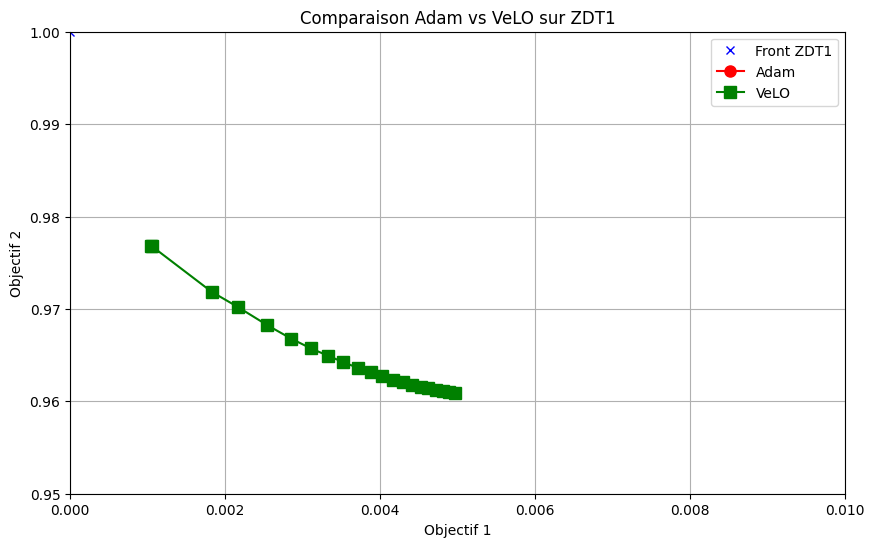

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(pareto_front_np[:, 0], pareto_front_np[:, 1], 'x', label="Front ZDT1", color='blue')
plt.plot(adam_np[:, 0], adam_np[:, 1], 'o-', label="Adam", color='red', markersize=8)
plt.plot(velo_np[:, 0], velo_np[:, 1], 's-', label="VeLO", color='green', markersize=8)

plt.xlabel("Objectif 1")
plt.ylabel("Objectif 2")
plt.title("Comparaison Adam vs VeLO sur ZDT1")
plt.xlim(0, 0.01)   # Par exemple, zoom sur les petites valeurs de f1
plt.ylim(0.95, 1.0) # Zoom sur la région de f2
plt.legend()
plt.grid(True)
plt.show()


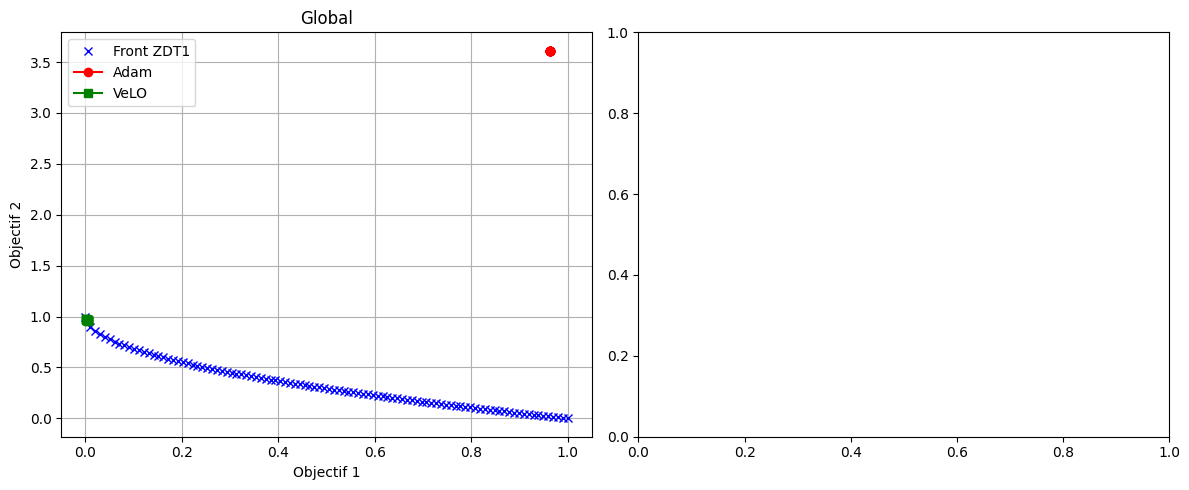

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# — Graphe global —
ax1.plot(pareto_front_np[:, 0], pareto_front_np[:, 1], 'x', label="Front ZDT1", color='blue')
ax1.plot(adam_np[:, 0], adam_np[:, 1], 'o-', label="Adam", color='red')
ax1.plot(velo_np[:, 0], velo_np[:, 1], 's-', label="VeLO", color='green')
ax1.set_title("Global")
ax1.set_xlabel("Objectif 1")
ax1.set_ylabel("Objectif 2")
ax1.legend()
ax1.grid(True)


plt.tight_layout()
plt.show()


In [ ]:
print("Nombre de points VeLO :", len(velo_points))
print("Points VeLO :", velo_points)


Nombre de points VeLO : 21
Points VeLO : [(0.004967515356838703, 0.9608597755432129), (0.004889354109764099, 0.9609719514846802), (0.004807920195162296, 0.9610936641693115), (0.004718956537544727, 0.9612351059913635), (0.004623295273631811, 0.9613938927650452), (0.004520645830780268, 0.9615784883499146), (0.004411123692989349, 0.9618013501167297), (0.004293525125831366, 0.9620649218559265), (0.004166487138718367, 0.9623611569404602), (0.004026899579912424, 0.9627156257629395), (0.003876641159877181, 0.9631320834159851), (0.003709417302161455, 0.9636296629905701), (0.0035260634031146765, 0.9642313122749329), (0.0033241338096559048, 0.9649461507797241), (0.003106913296505809, 0.9657246470451355), (0.002850963268429041, 0.9667860269546509), (0.0025460936594754457, 0.9682284593582153), (0.002159685827791691, 0.9702293276786804), (0.0018258629133924842, 0.9718512892723083), (0.0010529648279771209, 0.9767935276031494), (0.0010491745779290795, 0.9768191576004028)]


In [ ]:
task.problem.n_var = 2  # Override la dimension pour le test
task.dim = 2


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x_vals = np.linspace(0, 1, 100)
y_vals = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x_vals, y_vals)

Z = np.zeros_like(X)

# Poids choisis (on peut en tester plusieurs)
w1 = 0.5
w2 = 1 - w1

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        params = jnp.array([X[i, j], Y[i, j]])
        Z[i, j] = scalarized_loss(params, w1, w2)


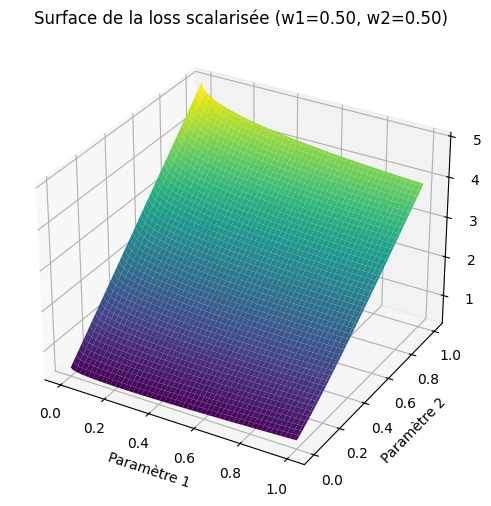

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel("Paramètre 1")
ax.set_ylabel("Paramètre 2")
ax.set_zlabel("Loss scalarisée")
ax.set_title(f"Surface de la loss scalarisée (w1={w1:.2f}, w2={w2:.2f})")
plt.show()


In [ ]:
#@title visualizing FashionMnist Loss

# here we visualize the loss during training
plt.plot(losses)

NameError: name 'losses' is not defined

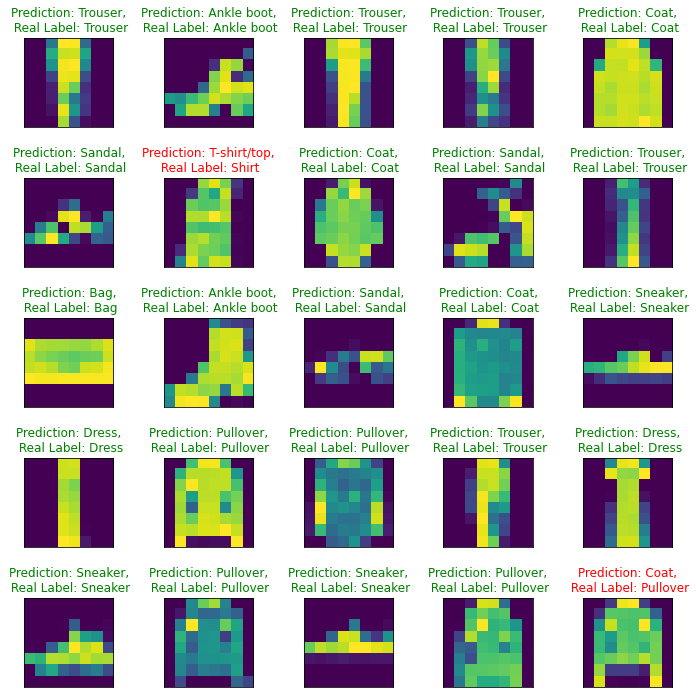

In [ ]:
# We can also inspect and visualize some model predictions:
predictions = task._mod.apply(params, key, batch["image"])
labels = batch["label"]

fashion_mnist_label_to_name = { 0:	"T-shirt/top",
                                1:	"Trouser",
                                2:	"Pullover",
                                3:	"Dress",
                                4:	"Coat",
                                5:	"Sandal",
                                6:	"Shirt",
                                7:	"Sneaker",
                                8:	"Bag",
                                9:	"Ankle boot"}

import matplotlib.pyplot as plt


fig, axs = plt.subplots(5, 5)
fig.set_size_inches(10, 10)
for i in range(5):
  for j in range(5):
    pred = fashion_mnist_label_to_name[int(jax.numpy.argmax(predictions,axis=1)[5*i+j])]
    real = fashion_mnist_label_to_name[labels[5*i+j]]
    color = 'g' if pred==real else 'r'
    axs[i, j].imshow(batch["image"][5*i+j])
    axs[i, j].set_title(f'Prediction: {pred},\n Real Label: {real}', color=color)
    axs[i, j].set_xticks([])
    axs[i, j].set_yticks([])

fig.tight_layout(pad=2.0)



# Training Resnets with VeLO


This example is meant to illustrate how to slot VeLO into a more mature training pipeline.  Below, we largely crib from the resnet training example in [jaxopt](https://jaxopt.github.io/stable/auto_examples/deep_learning/flax_resnet.html).


The main intervention necessary for VeLO to function is to make sure that it is provided the training loss as a feature.  Below, we perform the minimal necessary modifications to `jaxopt`'s `solver` interface to facilitate this plumbing.

In [ ]:
#@title imports, configuration, and model classes


!pip install jaxopt


from absl import app
from datetime import datetime

from functools import partial
from typing import Any, Callable, Sequence, Tuple

from flax import linen as nn

import jax
import jax.numpy as jnp

from jaxopt import loss
from jaxopt import OptaxSolver
from jaxopt import tree_util

import optax

import tensorflow_datasets as tfds
import tensorflow as tf


dataset_names = [
    "mnist", "kmnist", "emnist", "fashion_mnist", "cifar10", "cifar100"
]


L2REG = 1e-4
LEARNING_RATE = .2
EPOCHS = 10
MOMENTUM = .9
DATASET = 'cifar100' #@param [ "mnist", "kmnist", "emnist", "fashion_mnist", "cifar10", "cifar100"]
MODEL = 'resnet18' #@param ["resnet1", "resnet18", "resnet34"]
TRAIN_BATCH_SIZE = 256
TEST_BATCH_SIZE = 1024


def load_dataset(split, *, is_training, batch_size):
  version = 3
  ds, ds_info = tfds.load(
      f"{DATASET}:{version}.*.*",
      as_supervised=True,  # remove useless keys
      split=split,
      with_info=True)
  ds = ds.cache().repeat()
  if is_training:
    ds = ds.shuffle(10 * batch_size, seed=0)
  ds = ds.batch(batch_size)
  return iter(tfds.as_numpy(ds)), ds_info


class ResNetBlock(nn.Module):
  """ResNet block."""
  filters: int
  conv: Any
  norm: Any
  act: Callable
  strides: Tuple[int, int] = (1, 1)

  @nn.compact
  def __call__(self, x,):
    residual = x
    y = self.conv(self.filters, (3, 3), self.strides)(x)
    y = self.norm()(y)
    y = self.act(y)
    y = self.conv(self.filters, (3, 3))(y)
    y = self.norm(scale_init=nn.initializers.zeros)(y)

    if residual.shape != y.shape:
      residual = self.conv(self.filters, (1, 1),
                           self.strides, name='conv_proj')(residual)
      residual = self.norm(name='norm_proj')(residual)

    return self.act(residual + y)


class ResNet(nn.Module):
  """ResNetV1."""
  stage_sizes: Sequence[int]
  block_cls: Any
  num_classes: int
  num_filters: int = 64
  dtype: Any = jnp.float32
  act: Callable = nn.relu

  @nn.compact
  def __call__(self, x, train: bool = True):
    conv = partial(nn.Conv, use_bias=False, dtype=self.dtype)
    norm = partial(nn.BatchNorm,
                   use_running_average=not train,
                   momentum=0.9,
                   epsilon=1e-5,
                   dtype=self.dtype)

    x = conv(self.num_filters, (7, 7), (2, 2),
             padding=[(3, 3), (3, 3)],
             name='conv_init')(x)
    x = norm(name='bn_init')(x)
    x = nn.relu(x)
    x = nn.max_pool(x, (3, 3), strides=(2, 2), padding='SAME')
    for i, block_size in enumerate(self.stage_sizes):
      for j in range(block_size):
        strides = (2, 2) if i > 0 and j == 0 else (1, 1)
        x = self.block_cls(self.num_filters * 2 ** i,
                           strides=strides,
                           conv=conv,
                           norm=norm,
                           act=self.act)(x)
    x = jnp.mean(x, axis=(1, 2))
    x = nn.Dense(self.num_classes, dtype=self.dtype)(x)
    x = jnp.asarray(x, self.dtype)
    return x


ResNet1 = partial(ResNet, stage_sizes=[1], block_cls=ResNetBlock)
ResNet18 = partial(ResNet, stage_sizes=[2, 2, 2, 2], block_cls=ResNetBlock)
ResNet34 = partial(ResNet, stage_sizes=[3, 4, 6, 3], block_cls=ResNetBlock)




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 4.5 MB/s eta 0:00:00


In [ ]:
#@title training loop definition (run this cell to launch training)
import functools
from typing import Any
from typing import Callable
from typing import NamedTuple
from typing import Optional

from dataclasses import dataclass

import jax
import jax.numpy as jnp

from jaxopt._src import base
from jaxopt._src import tree_util



class OptaxState(NamedTuple):
  """Named tuple containing state information."""
  iter_num: int
  value: float
  error: float
  internal_state: NamedTuple
  aux: Any

# we need to reimplement optax's OptaxSolver's lopt_update method to properly pass in the loss data that VeLO expects.
def lopt_update(self,
            params: Any,
            state: NamedTuple,
            *args,
            **kwargs) -> base.OptStep:
  """Performs one iteration of the optax solver.

  Args:
    params: pytree containing the parameters.
    state: named tuple containing the solver state.
    *args: additional positional arguments to be passed to ``fun``.
    **kwargs: additional keyword arguments to be passed to ``fun``.
  Returns:
    (params, state)
  """
  if self.pre_update:
    params, state = self.pre_update(params, state, *args, **kwargs)

  (value, aux), grad = self._value_and_grad_fun(params, *args, **kwargs)

  # note the only difference between this function and the baseline
  # optax.OptaxSolver.lopt_update is that `extra_args` is now passed.
  # if you would like to use a different optimizer, you will likely need to
  # remove these extra_args.
  delta, opt_state = self.opt.update(grad, state.internal_state, params, extra_args={"loss": value})
  params = self._apply_updates(params, delta)

  # Computes optimality error before update to re-use grad evaluation.
  new_state = OptaxState(iter_num=state.iter_num + 1,
                          error=tree_util.tree_l2_norm(grad),
                          value=value,
                          aux=aux,
                          internal_state=opt_state)
  return base.OptStep(params=params, state=new_state)




def train():

  # Hide any GPUs from TensorFlow. Otherwise TF might reserve memory and make
  # it unavailable to JAX.
  # tf.config.experimental.set_visible_devices([], 'GPU')


  # typical data loading and iterator setup

  train_ds, ds_info = load_dataset("train", is_training=True,
                                    batch_size=TRAIN_BATCH_SIZE)
  test_ds, _ = load_dataset("test", is_training=False,
                            batch_size=TEST_BATCH_SIZE)
  input_shape = (1,) + ds_info.features["image"].shape
  num_classes = ds_info.features["label"].num_classes
  iter_per_epoch_train = ds_info.splits['train'].num_examples // TRAIN_BATCH_SIZE
  iter_per_epoch_test = ds_info.splits['test'].num_examples // TEST_BATCH_SIZE

  # Set up model.
  if MODEL == "resnet1":
    net = ResNet1(num_classes=num_classes)
  elif MODEL == "resnet18":
    net = ResNet18(num_classes=num_classes)
  elif MODEL == "resnet34":
    net = ResNet34(num_classes=num_classes)
  else:
    raise ValueError("Unknown model.")

  def predict(params, inputs, aux, train=False):
    x = inputs.astype(jnp.float32) / 255.
    all_params = {"params": params, "batch_stats": aux}
    if train:
      # Returns logits and net_state (which contains the key "batch_stats").
      return net.apply(all_params, x, train=True, mutable=["batch_stats"])
    else:
      # Returns logits only.
      return net.apply(all_params, x, train=False)

  logistic_loss = jax.vmap(loss.multiclass_logistic_loss)

  def loss_from_logits(params, l2reg, logits, labels):
    mean_loss = jnp.mean(logistic_loss(labels, logits))
    sqnorm = tree_util.tree_l2_norm(params, squared=True)
    return mean_loss + 0.5 * l2reg * sqnorm

  def accuracy_and_loss(params, l2reg, data, aux):
    inputs, labels = data
    logits = predict(params, inputs, aux)
    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    loss = loss_from_logits(params, l2reg, logits, labels)
    return accuracy, loss

  def loss_fun(params, l2reg, data, aux):
    inputs, labels = data
    logits, net_state = predict(params, inputs, aux, train=True)
    loss = loss_from_logits(params, l2reg, logits, labels)
    # batch_stats will be stored in state.aux
    return loss, net_state["batch_stats"]

  # The default optimizer used by jaxopt is commented out here
  # opt = optax.sgd(learning_rate=LEARNING_RATE,
  #                 momentum=MOMENTUM,
  #                 nesterov=True)

  NUM_STEPS = EPOCHS * iter_per_epoch_train
  opt = prefab.optax_lopt(NUM_STEPS)

  # We need has_aux=True because loss_fun returns batch_stats.
  solver = OptaxSolver(opt=opt,
                       fun=jax.value_and_grad(loss_fun, has_aux=True),
                       maxiter=EPOCHS * iter_per_epoch_train,
                       has_aux=True,
                       value_and_grad=True)

  # Initialize parameters.
  rng = jax.random.PRNGKey(0)
  init_vars = net.init(rng, jnp.zeros(input_shape), train=True)
  params = init_vars["params"]
  batch_stats = init_vars["batch_stats"]
  start = datetime.now().replace(microsecond=0)

  # Run training loop.
  state = solver.init_state(params, L2REG, next(test_ds), batch_stats)
  jitted_update = jax.jit(functools.partial(lopt_update, self=solver))
  print(f'Iterations: {solver.maxiter}')

  for _ in range(solver.maxiter):
    train_minibatch = next(train_ds)

    if state.iter_num % iter_per_epoch_train == iter_per_epoch_train - 1:
      # Once per epoch evaluate the model on the train and test sets.
      test_acc, test_loss = 0., 0.
      # make a pass over test set to compute test accuracy
      for _ in range(iter_per_epoch_test):
          tmp = accuracy_and_loss(params, L2REG, next(test_ds), batch_stats)
          test_acc += tmp[0] / iter_per_epoch_test
          test_loss += tmp[1] / iter_per_epoch_test

      train_acc, train_loss = 0., 0.
      # make a pass over train set to compute train accuracy
      for _ in range(iter_per_epoch_train):
          tmp = accuracy_and_loss(params, L2REG, next(train_ds), batch_stats)
          train_acc += tmp[0] / iter_per_epoch_train
          train_loss += tmp[1] / iter_per_epoch_train

      train_acc = jax.device_get(train_acc)
      train_loss = jax.device_get(train_loss)
      test_acc = jax.device_get(test_acc)
      test_loss = jax.device_get(test_loss)
      # time elapsed without microseconds
      time_elapsed = (datetime.now().replace(microsecond=0) - start)

      print(f"[Epoch {(state.iter_num+1) // (iter_per_epoch_train+1)}/{EPOCHS}] "
            f"Train acc: {train_acc:.3f}, train loss: {train_loss:.3f}. "
            f"Test acc: {test_acc:.3f}, test loss: {test_loss:.3f}. "
            f"Time elapsed: {time_elapsed}")

    params, state = jitted_update(params=params,
                                  state=state,
                                  l2reg=L2REG,
                                  data=train_minibatch,
                                  aux=batch_stats)
    batch_stats = state.aux

train()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar100/incomplete.FRYR7R_3.0.2/cifar100-train.tfrecord*...:   0%|       …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar100/incomplete.FRYR7R_3.0.2/cifar100-test.tfrecord*...:   0%|        …

Dataset cifar100 downloaded and prepared to /root/tensorflow_datasets/cifar100/3.0.2. Subsequent calls will reuse this data.
opt_from_checkpoint__5b422876_9dbd_446c_bc6f_ea01bc12647d/Adam.learning_rate = 0.0003
opt_from_checkpoint__5b422876_9dbd_446c_bc6f_ea01bc12647d/build_gradient_estimators.gradient_estimator_fn = @FullESOrPMAP
opt_from_checkpoint__5b422876_9dbd_446c_bc6f_ea01bc12647d/build_gradient_estimators.sample_task_family_fn = @april28_distribution_bigger
opt_from_checkpoint__5b422876_9dbd_446c_bc6f_ea01bc12647d/FullES.loss_type = 'last_recompute'
opt_from_checkpoint__5b422876_9dbd_446c_bc6f_ea01bc12647d/FullES.recompute_samples = 100
opt_from_checkpoint__5b422876_9dbd_446c_bc6f_ea01bc12647d/FullES.sign_delta_loss_scalar = 1.0
opt_from_checkpoint__5b422876_9dbd_446c_bc6f_ea01bc12647d/FullES.truncation_schedule = @LogUniformLengthSchedule()
opt_from_checkpoint__5b422876_9dbd_446c_bc6f_ea01bc12647d/gradient_worker_compute.extra_metrics = False
opt_from_checkpoint__5b422876_9dbd

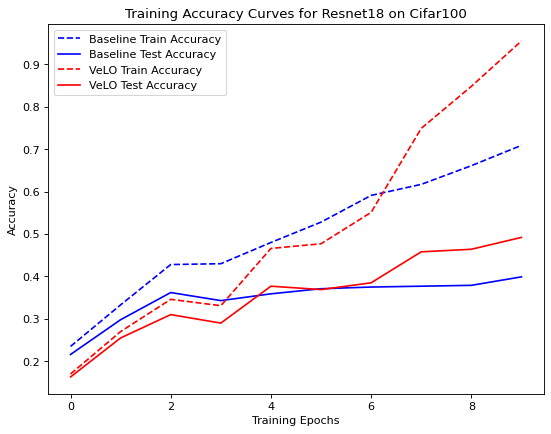

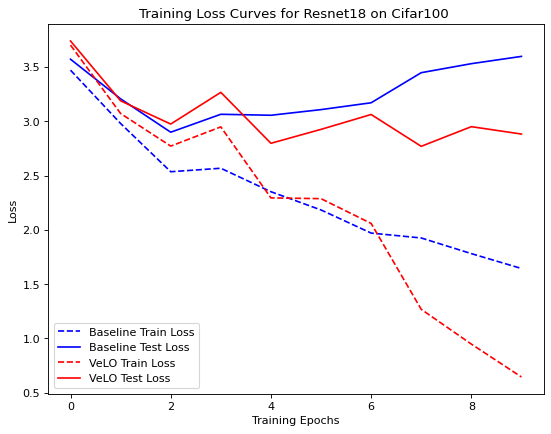

In [ ]:
#@title Comparing a baseline optimizer vs. VeLO on resnet18 cifar100.
baseline_train_acc = [0.235,
0.333,
0.428,
0.430,
0.480,
0.528,
0.591,
0.617,
0.661,
0.709,]

baseline_test_acc = [0.216,
0.298,
0.362,
0.343,
0.359,
0.371,
0.375,
0.377,
0.379,
0.399,]


velo_train_acc = [0.170,
0.270,
0.346,
0.331,
0.466,
0.477,
0.551,
0.749,
0.848,
0.955,]

velo_test_acc = [0.163,
0.255,
0.310,
0.290,
0.377,
0.369,
0.385,
0.458,
0.464,
0.492,]


from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=80)

plt.plot(range(10), baseline_train_acc, label="Baseline Train Accuracy", c='b',  linestyle='dashed')
plt.plot(range(10), baseline_test_acc, label = "Baseline Test Accuracy", c='b')
plt.plot(range(10), velo_train_acc, label= "VeLO Train Accuracy", c='r', linestyle='dashed')
plt.plot(range(10), velo_test_acc, label="VeLO Test Accuracy", c='r')
plt.xlabel("Training Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curves for Resnet18 on Cifar100")
plt.legend()
plt.show()






#@title Comparing a baseline optimizer vs. VeLO on resnet18 cifar100.
baseline_train_loss = [3.470,
2.979,
2.535,
2.567,
2.351,
2.183,
1.970,
1.925,
1.781,
1.644,]

baseline_test_loss = [3.571,
3.206,
2.899,
3.064,
3.055,
3.107,
3.170,
3.447,
3.530,
3.597,]


velo_train_loss = [3.701,
3.071,
2.771,
2.948,
2.294,
2.287,
2.059,
1.268,
0.948,
0.645,]

velo_test_loss = [3.739,
3.188,
2.974,
3.266,
2.797,
2.925,
3.062,
2.769,
2.950,
2.882]


from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=80)

plt.plot(range(10), baseline_train_loss, label="Baseline Train Loss", c='b',  linestyle='dashed')
plt.plot(range(10), baseline_test_loss, label = "Baseline Test Loss", c='b')
plt.plot(range(10), velo_train_loss, label= "VeLO Train Loss", c='r', linestyle='dashed')
plt.plot(range(10), velo_test_loss, label="VeLO Test Loss", c='r')
plt.xlabel("Training Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curves for Resnet18 on Cifar100 ")
plt.legend()
plt.show()